In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [28]:
divorce = pd.read_csv('../resources/divorce.csv')

In [29]:
divorce.head()

,divorce_date,dob_man,education_man,income_man,dob_woman,education_woman,income_woman,marriage_date,marriage_duration,num_kids
0,2006-09-06,1975-12-18,Secondary,2000.0,1983-08-01,Secondary,1800.0,2000-06-26,5.0,1.0
1,2008-01-02,1976-11-17,Professional,6000.0,1977-03-13,Professional,6000.0,2001-09-02,7.0,NaN
2,2011-01-02,1969-04-06,Preparatory,5000.0,1970-02-16,Professional,5000.0,2000-02-02,2.0,2.0
3,2011-01-02,1979-11-13,Secondary,12000.0,1981-05-13,Secondary,12000.0,2006-05-13,2.0,NaN
4,2011-01-02,1982-09-20,Professional,6000.0,1988-01-30,Professional,10000.0,2007-08-06,3.0,NaN


In [30]:
divorce.dtypes

divorce_date             str
dob_man                  str
education_man            str
income_man           float64
dob_woman                str
education_woman          str
income_woman         float64
marriage_date            str
marriage_duration    float64
num_kids             float64
dtype: object

# importing date time to the dataset

In [31]:
divorce = pd.read_csv('../resources/divorce.csv',parse_dates=['marriage_date','dob_man','divorce_date','dob_woman'])
divorce.dtypes

divorce_date         datetime64[us]
dob_man              datetime64[us]
education_man                   str
income_man                  float64
dob_woman            datetime64[us]
education_woman                 str
income_woman                float64
marriage_date        datetime64[us]
marriage_duration           float64
num_kids                    float64
dtype: object

# Creating date time data

In [32]:
divorce['marriage_month'] = divorce['marriage_date'].dt.month
divorce['marriage_year'] = divorce['marriage_date'].dt.year
divorce.head()

,divorce_date,dob_man,education_man,income_man,dob_woman,education_woman,income_woman,marriage_date,marriage_duration,num_kids,marriage_month,marriage_year
0,2006-09-06,1975-12-18,Secondary,2000.0,1983-08-01,Secondary,1800.0,2000-06-26,5.0,1.0,6,2000
1,2008-01-02,1976-11-17,Professional,6000.0,1977-03-13,Professional,6000.0,2001-09-02,7.0,NaN,9,2001
2,2011-01-02,1969-04-06,Preparatory,5000.0,1970-02-16,Professional,5000.0,2000-02-02,2.0,2.0,2,2000
3,2011-01-02,1979-11-13,Secondary,12000.0,1981-05-13,Secondary,12000.0,2006-05-13,2.0,NaN,5,2006
4,2011-01-02,1982-09-20,Professional,6000.0,1988-01-30,Professional,10000.0,2007-08-06,3.0,NaN,8,2007


<Axes: xlabel='marriage_month', ylabel='marriage_duration'>

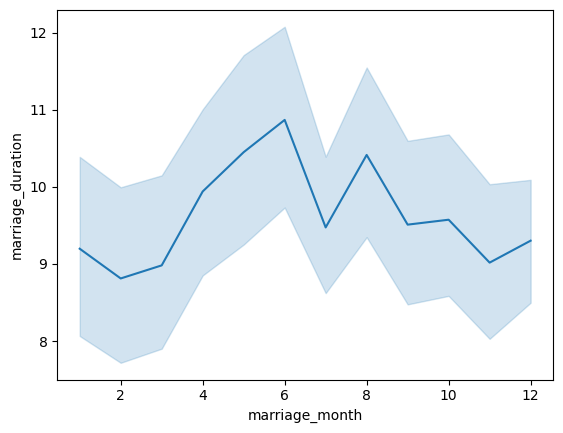

In [33]:
sns.lineplot(
    data=divorce,
    x='marriage_month',
    y='marriage_duration'
)

# Correlation
- Describes direction and strength of relationships between two variables 
- set **Set numeric_only=True** to prevent errors with non_numeric columns

In [34]:
divorce.corr(numeric_only=True)

,income_man,income_woman,marriage_duration,num_kids,marriage_month,marriage_year
income_man,1.000000,0.318047,0.085321,0.040848,0.013652,0.019170
income_woman,0.318047,1.000000,0.078677,-0.018015,0.041441,0.026433
marriage_duration,0.085321,0.078677,1.000000,0.447358,0.001433,-0.812469
num_kids,0.040848,-0.018015,0.447358,1.000000,-0.000551,-0.461495
marriage_month,0.013652,0.041441,0.001433,-0.000551,1.000000,-0.011456
marriage_year,0.019170,0.026433,-0.812469,-0.461495,-0.011456,1.000000


<Axes: >

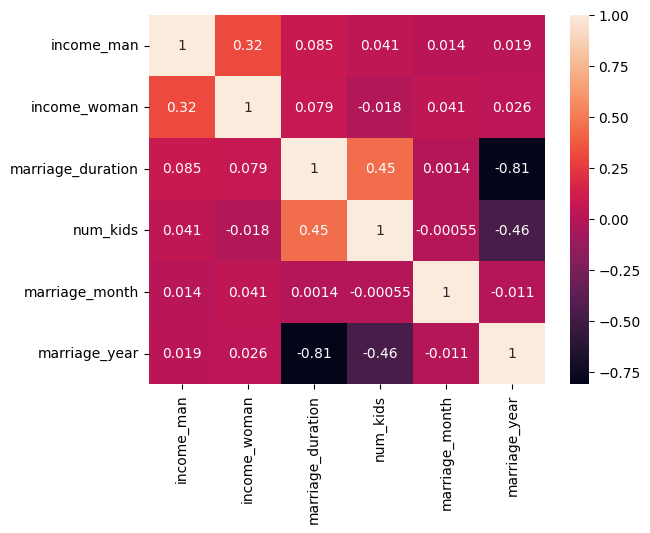

In [35]:
sns.heatmap(divorce.corr(numeric_only=True),annot=True)

<Axes: xlabel='income_man', ylabel='income_woman'>

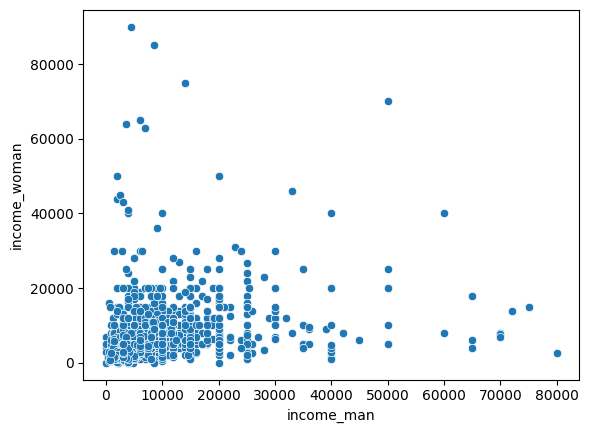

In [36]:
sns.scatterplot(
    data=divorce,
    x='income_man',
    y='income_woman'
)

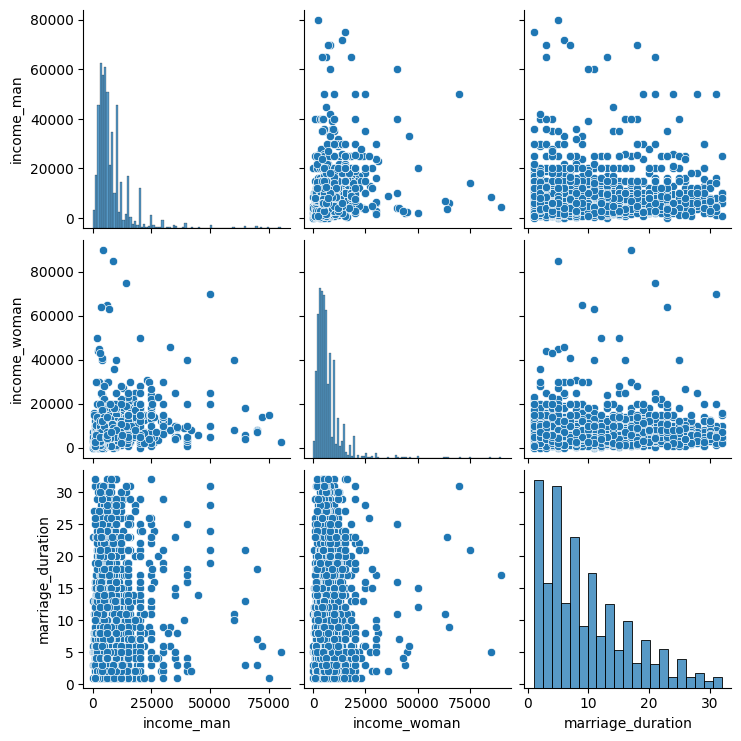

In [37]:
sns.pairplot(
    data=divorce,
    vars=['income_man','income_woman','marriage_duration']
)
plt.show()

In [38]:
divorce['education_man'].value_counts()

education_man
Professional    1313
Preparatory      501
Secondary        288
Primary          100
Other              3
Name: count, dtype: int64

<Axes: xlabel='marriage_duration', ylabel='Count'>

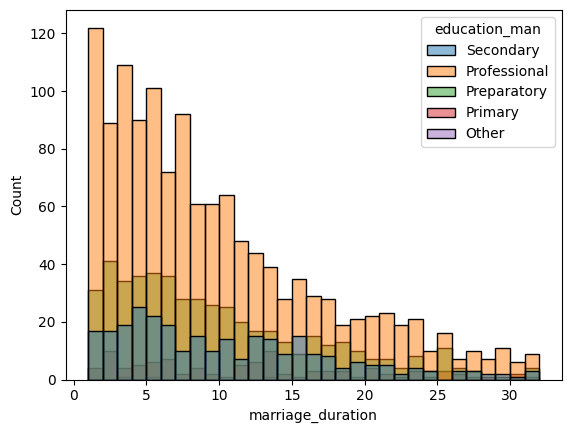

In [39]:
sns.histplot(
    data=divorce,
    x='marriage_duration',
    hue='education_man',
    binwidth=1
)

# Kernal Density Estimate

<Axes: xlabel='marriage_duration', ylabel='Density'>

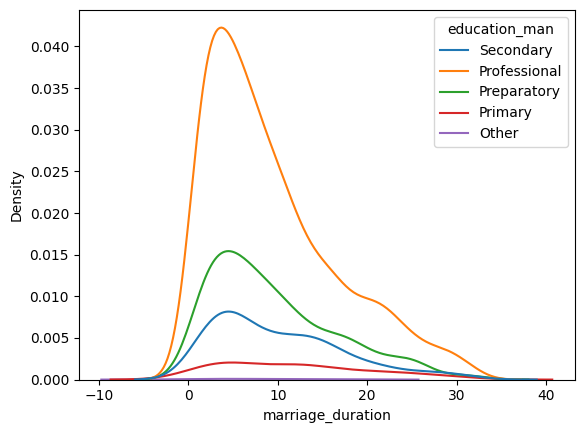

In [40]:
sns.kdeplot(
    data=divorce,
    x='marriage_duration',
    hue='education_man'
)

<Axes: xlabel='marriage_duration', ylabel='Density'>

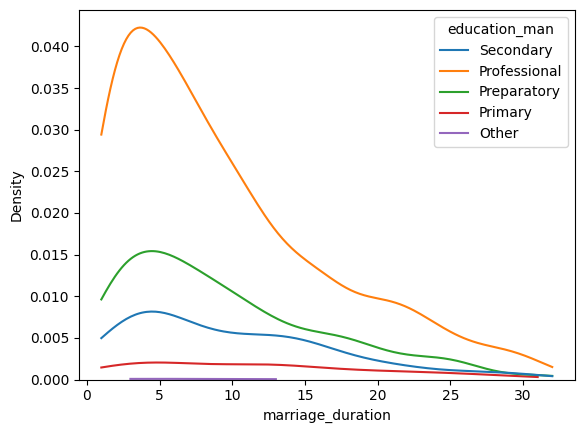

In [41]:
sns.kdeplot(
    data=divorce,
    x='marriage_duration',
    hue='education_man',
    cut=0
)

<Axes: xlabel='marriage_duration', ylabel='Density'>

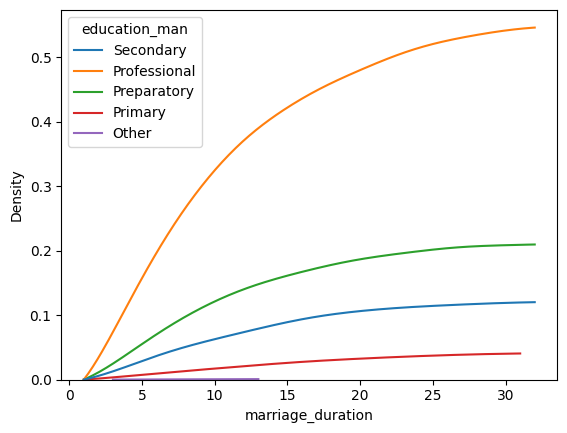

In [42]:
sns.kdeplot(
    data=divorce,
    x='marriage_duration',
    hue='education_man',
    cut=0,
    cumulative=True
)

# Relatiion between marriage age and education
- is there a relation between age at marrige and education level 

In [46]:
df.dtypes

divorce_date             str
dob_man                  str
education_man            str
income_man           float64
dob_woman                str
education_woman          str
income_woman         float64
marriage_date            str
marriage_duration    float64
num_kids             float64
dtype: object

In [47]:
divorce['dob_man']

0      1975-12-18
1      1976-11-17
2      1969-04-06
3      1979-11-13
4      1982-09-20
          ...    
2204   1969-11-27
2205   1970-09-17
2206   1976-03-11
2207   1977-10-29
2208   1960-06-22
Name: dob_man, Length: 2209, dtype: datetime64[us]

In [48]:
divorce['man_age_marriage'] = divorce['marriage_year'] - divorce['dob_man'].dt.year
divorce['woman_age_marriage'] = divorce['marriage_year'] - divorce['dob_woman'].dt.year

<Axes: xlabel='woman_age_marriage', ylabel='man_age_marriage'>

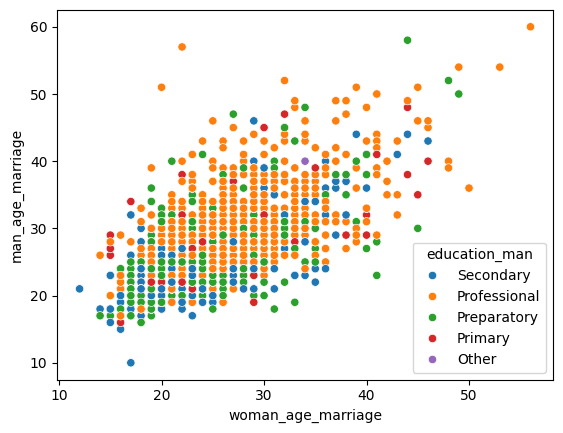

In [50]:
sns.scatterplot(
    data=divorce,
    x='woman_age_marriage',
    y='man_age_marriage',
    hue='education_man'
)